# LAPORAN ANALISIS DATA KUALITAS UDARA KECAMATAN LABANG (KONSENTRASI CO)

## Penanganan Missing Value (Imputasi Data)

Penanganan nilai yang hilang (missing values) merupakan tahap fundamental dalam pra-pemrosesan data deret waktu (time series) kualitas udara, khususnya pada parameter gas polutan seperti Karbon Monoksida (CO). Kehadiran data yang kosong (NaN) secara signifikan dapat merusak kontinuitas temporal, mengganggu perhitungan metrik statistik lanjutan, serta mendistorsi hasil ekstraksi fitur berbasis jendela waktu (windowing). Oleh karena itu, diperlukan prosedur imputasi yang andal untuk merekonstruksi titik data yang hilang tanpa merusak struktur tren historis aslinya.

### Pendekatan Metodologi
Prosedur pengisian nilai-nilai yang hilang (missing values) pada deret waktu (time series) kualitas udara agar kesinambungan data tetap terjaga tanpa mengubah pola tren histori.

### Alur Kerja Teknis

* Deteksi dan Lokalisasi Celah Data: Melakukan pemindaian pada seluruh matriks waktu untuk mengidentifikasi indeks baris yang mengalami kekosongan nilai akibat kegagalan sensor atau kendala transmisi data.  
* Estimasi Nilai Berbasis Titik Terdekat: Mengisi celah kosong dengan menarik garis lurus imajiner yang menghubungkan titik data valid tepat sebelum (preceding point) dan tepat sesudah (succeeding point) area yang kosong.  
* Rekonstruksi Sekuensial: Menerapkan perhitungan secara berurutan menelusuri sumbu waktu guna memastikan transisi nilai tetap mulus dan konsisten dengan dinamika fluktuasi polutan harian.  

### Formulasi Matematis Interpolasi Linier

Secara analitis, nilai estimasi pada titik waktu yang hilang dihitung menggunakan persamaan geometris linier dua titik:$$y = y_1 + \frac{(x - x_1)(y_2 - y_1)}{x_2 - x_1}$$  
**Keterangan Variabel:**
* $y$ : Nilai konsentrasi polutan CO yang diestimasi pada titik waktu target $x$.  
* $x_1, y_1$ : Koordinat waktu dan nilai konsentrasi pada titik valid sebelum celah kosong.  
* $x_2, y_2$ : Koordinat waktu dan nilai konsentrasi pada titik valid setelah celah kosong.  

In [12]:
import pandas as pd
import numpy as np
import os

# --- 1. Lakukan untuk 1 polutan saja dahulu (CO) ---
# Kode ini akan otomatis mencari lokasi CSV yang benar
if os.path.exists('CO_labang_timeseries.csv'):
    df = pd.read_csv('CO_labang_timeseries.csv')
elif os.path.exists('materi/CO_labang_timeseries.csv'):
    df = pd.read_csv('materi/CO_labang_timeseries.csv')
else:
    print("ERROR: File CSV belum ditemukan di folder ini atau folder materi!")

# Asumsi nama kolom waktu adalah 'date' dan polutan adalah 'CO'
df_co = df[['date', 'CO']].copy()
df_co['date'] = pd.to_datetime(df_co['date'])

# --- 2. Menangani missing values dengan teknik imputasi ---
# Menggunakan interpolasi linier agar pola tren waktu tidak rusak
df_co['CO_imputed'] = df_co['CO'].interpolate(method='linear').bfill().ffill()

print("Missing values sebelum imputasi:", df_co['CO'].isnull().sum())
print("Missing values setelah imputasi:", df_co['CO_imputed'].isnull().sum())

Missing values sebelum imputasi: 183
Missing values setelah imputasi: 0


## Deteksi dan Perbaikan Outlier

Keberadaan data pencilan (outlier) merupakan salah satu tantangan utama dalam analisis deret waktu (time series) lingkungan dan kualitas udara. Pada parameter konsentrasi Karbon Monoksida (CO), outlier dapat termanifestasi sebagai anomali ekstrem yang disebabkan oleh galat sensor (sensor glitch), gangguan transmisi data, atau kejadian luar biasa sesaat (seperti kebakaran hutan atau kemacetan total mendadak). Jika tidak ditangani, pencilan ini dapat mendistorsi parameter statistik deskriptif, mengacaukan perhitungan jarak kemiripan (similarity metrics), dan menghasilkan ekstraksi fitur yang bias.

### Pendekatan Metodologi
Untuk mendeteksi pencilan secara objektif tanpa mengasumsikan distribusi data harus normal secara sempurna, digunakan metode non-parametrik berbasis Rentang Interkuartil (Interquartile Range / IQR). Metode ini sangat efektif untuk data lingkungan yang umumnya memiliki sebaran menceng (skewed distribution). Setelah pencilan teridentifikasi, proses perbaikan dilakukan melalui teknik pembatasan nilai (clipping atau capping) alih-alih penghapusan baris, guna menjaga panjang sekuens data tetap konsisten sebanyak 365 hari penuh.

### Alur Kerja Teknis

* Ekstraksi Kuartil Statistik: Menghitung nilai Kuartil Pertama ($Q_1$ pada persentil ke-25) dan Kuartil Ketiga ($Q_3$ pada persentil ke-75) dari data konsentrasi CO yang telah melalui tahap imputasi.
* Kalkulasi Rentang Interkuartil (IQR): Menentukan selisih antara kuartil atas dan kuartil bawah untuk mengukur penyebaran 50% data tengah.
* Penetapan Batas Toleransi (Bounds): Menghitung ambang batas bawah dan batas atas menggunakan pengali standar 1.5 kali IQR. Nilai yang berada di luar rentang ini diklasifikasikan secara formal sebagai outlier.
* Rekonstruksi Nilai (Clipping/Capping): Mengganti nilai ekstrem yang melampaui batas toleransi dengan nilai ambang batas terdekat (batas atas atau batas bawah maksimum), sehingga tren umum tetap terjaga tanpa menciptakan celah data baru.

### Formulasi Matematis IQR dan Batas Toleransi
Secara analitis, batas deteksi pencilan dirumuskan melalui persamaan berikut:$$\text{IQR} = Q_3 - Q_1$$$$\text{Batas Bawah} = Q_1 - 1.5 \times \text{IQR}$$$$\text{Batas Atas} = Q_3 + 1.5 \times \text{IQR}$$
**Keterangan Variabel:**
* $Q_1$ : Nilai pada persentil ke-25 dari sebaran data konsentrasi CO.
* $Q_3$ : Nilai pada persentil ke-75 dari sebaran data konsentrasi CO.
* $\text{IQR}$ : Lebar interkuartil yang merepresentasikan variabilitas data pusat.
* Faktor pengali $1.5$ : Standar statistik empiris untuk mendeteksi outlier moderat hingga ekstrem.

Batas Bawah: 0.020405300925
Batas Atas: 0.03714660779166667
Jumlah Outlier terdeteksi: 6


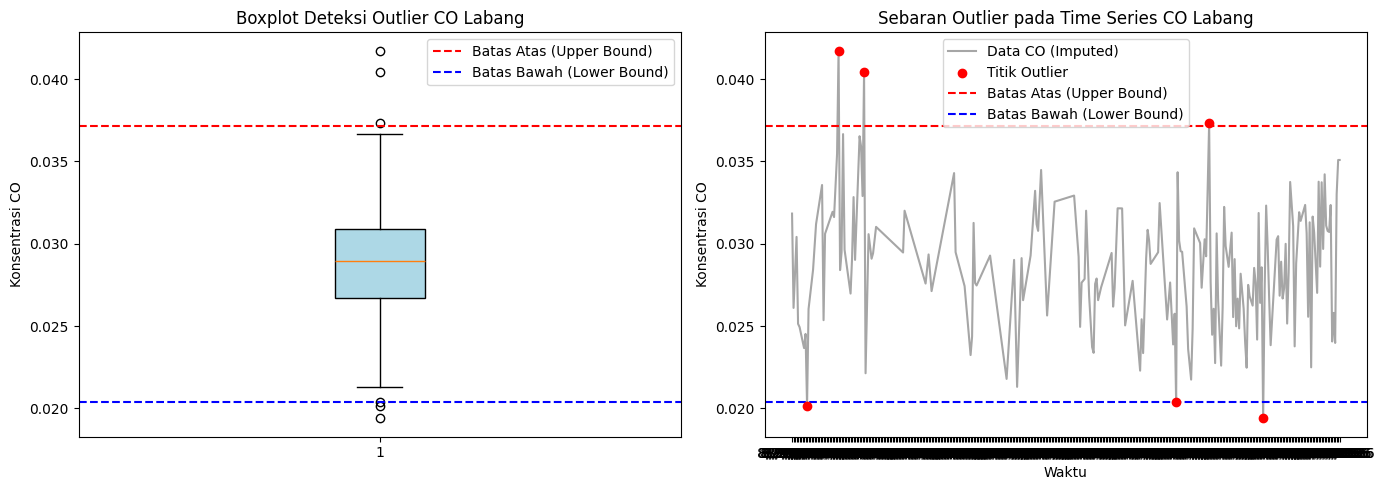

In [5]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# --- 1. PERHITUNGAN IQR & DETEKSI OUTLIER ---
# (Pastikan df_co dan kolom 'CO_imputed' sudah ada dari sel sebelumnya)

# Menghitung Kuartil 1 (Q1) dan Kuartil 3 (Q3)
Q1 = df_co["CO_imputed"].quantile(0.25)
Q3 = df_co["CO_imputed"].quantile(0.75)

# Menghitung rentang interkuartil (IQR)
IQR = Q3 - Q1

# Menentukan Batas Bawah dan Batas Atas (Sesuai rumus di Bab 2)
batas_bawah = Q1 - 1.5 * IQR
batas_atas = Q3 + 1.5 * IQR

# Memisahkan data yang teridentifikasi sebagai outlier untuk ditandai di grafik
outliers = df_co[(df_co["CO_imputed"] < batas_bawah) | (df_co["CO_imputed"] > batas_atas)]

print(f"Batas Bawah: {batas_bawah}")
print(f"Batas Atas: {batas_atas}")
print(f"Jumlah Outlier terdeteksi: {len(outliers)}")


# --- 2. VISUALISASI ---
# Menyiapkan Canvas untuk 2 Subplot (Boxplot & Time Series)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Subplot 1: Boxplot (Kiri)
ax1.boxplot(df_co["CO_imputed"], vert=True, patch_artist=True, boxprops=dict(facecolor='lightblue'))
ax1.set_title("Boxplot Deteksi Outlier CO Labang")
ax1.set_ylabel("Konsentrasi CO")
ax1.axhline(batas_atas, color="red", linestyle="--", label="Batas Atas (Upper Bound)")
ax1.axhline(batas_bawah, color="blue", linestyle="--", label="Batas Bawah (Lower Bound)")
ax1.legend()

# Subplot 2: Time Series dengan Titik Outlier (Kanan)
ax2.plot(df_co["date"], df_co["CO_imputed"], label="Data CO (Imputed)", color="gray", alpha=0.7)

# Memberi tanda titik merah tebal pada nilai yang teridentifikasi sebagai outlier
ax2.scatter(
    outliers["date"],
    outliers["CO_imputed"],
    color="red",
    label="Titik Outlier",
    zorder=5,
)
ax2.axhline(batas_atas, color="red", linestyle="--", label="Batas Atas (Upper Bound)")
ax2.axhline(batas_bawah, color="blue", linestyle="--", label="Batas Bawah (Lower Bound)")

ax2.set_title("Sebaran Outlier pada Time Series CO Labang")
ax2.set_xlabel("Waktu")
ax2.set_ylabel("Konsentrasi CO")
ax2.legend()

# Menampilkan gambar dengan layout yang rapi
plt.tight_layout()
plt.show()

In [6]:
import pandas as pd
import numpy as np

# 1. Baca data asli
df_co = pd.read_csv('CO_labang_timeseries.csv')

# 2. Lakukan imputasi (jika belum)
df_co["CO_imputed"] = df_co["CO"].interpolate(method='linear').bfill().ffill()

# 3. Hitung IQR & Batas Outlier
Q1 = df_co["CO_imputed"].quantile(0.25)
Q3 = df_co["CO_imputed"].quantile(0.75)
IQR = Q3 - Q1
batas_bawah = Q1 - 1.5 * IQR
batas_atas = Q3 + 1.5 * IQR

# 4. Perbaikan Outlier (Clipping)
df_co["CO_cleaned"] = df_co["CO_imputed"].clip(lower=batas_bawah, upper=batas_atas)

print("=== Hasil Perbaikan Outlier Selesai ===")
print(f"Nilai Max Sebelum Dibersihkan : {df_co['CO_imputed'].max():.4f}")
print(f"Nilai Max Setelah Dibersihkan  : {df_co['CO_cleaned'].max():.4f}")

# 5. Simpan file agar benar-benar ada di direktori Colab
df_co.to_csv("CO_labang_cleaned.csv", index=False)
print("\nFile 'CO_labang_cleaned.csv' berhasil dibuat dan disimpan!")

=== Hasil Perbaikan Outlier Selesai ===
Nilai Max Sebelum Dibersihkan : 0.0417
Nilai Max Setelah Dibersihkan  : 0.0371

File 'CO_labang_cleaned.csv' berhasil dibuat dan disimpan!


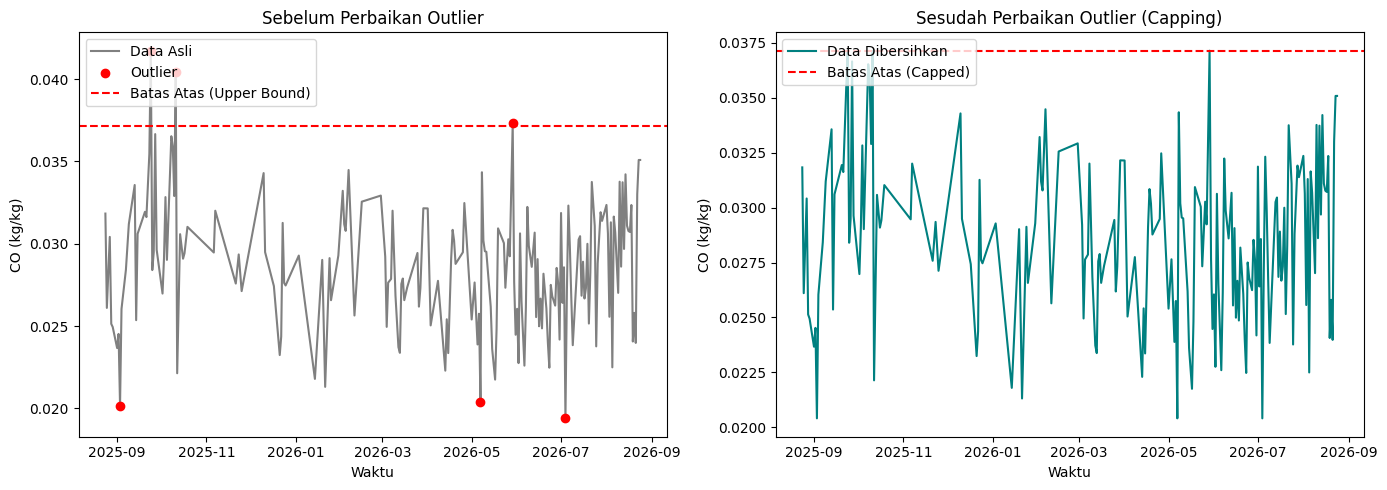

In [7]:
import matplotlib.pyplot as plt
import pandas as pd

# 1. Pastikan kolom tanggal benar-benar berformat datetime
df_co["date"] = pd.to_datetime(df_co["date"])
outliers["date"] = pd.to_datetime(outliers["date"])

# 2. Menyiapkan Canvas 2 Subplot berdampingan
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# --- SUBPLOT 1: SEBELUM PERBAIKAN OUTLIER ---
ax1.plot(df_co["date"], df_co["CO_imputed"], color="gray", label="Data Asli")
ax1.scatter(
    outliers["date"],
    outliers["CO_imputed"],
    color="red",
    label="Outlier",
    zorder=5,
)
ax1.axhline(
    batas_atas, color="red", linestyle="--", label="Batas Atas (Upper Bound)"
)
ax1.set_title("Sebelum Perbaikan Outlier")
ax1.set_xlabel("Waktu")
ax1.set_ylabel("CO (kg/kg)")
ax1.legend(loc="upper left")

# --- SUBPLOT 2: SESUDAH PERBAIKAN OUTLIER (Capping) ---
ax2.plot(
    df_co["date"], df_co["CO_cleaned"], color="teal", label="Data Dibersihkan"
)
ax2.axhline(
    batas_atas, color="red", linestyle="--", label="Batas Atas (Capped)"
)
ax2.set_title("Sesudah Perbaikan Outlier (Capping)")
ax2.set_xlabel("Waktu")
ax2.set_ylabel("CO (kg/kg)")
ax2.legend(loc="upper left")

# Mengatur tata letak agar rapi dan menampilkannya
plt.tight_layout()
plt.show()

In [9]:
!pip install tsfel

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.4/63.4 kB 6.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 116.9 MB/s eta 0:00:00


# Ekstraksi dan Pemahaman 68 Fitur

Transformasi data deret waktu mentah (raw time series) menjadi representasi vektor numerik yang bermakna merupakan inti dari feature engineering. Pada tahap ini, keseluruhan data harian konsentrasi Karbon Monoksida (CO) sepanjang 365 hari yang telah melalui proses pembersihan diekstrak fiturnya menggunakan pustaka Time Series Feature Extraction Library (TSFEL). Ekstraksi ini dirancang untuk menangkap karakteristik tersembunyi dari sinyal melalui tiga domain utama: Statistik (Statistical), Temporal, dan Spektral (Spectral).

In [10]:


import pandas as pd
import tsfel

# Memuat data bersih yang sudah disimpan
df_co = pd.read_csv("CO_labang_cleaned.csv")

# --- EKSTRAKSI FITUR TSFEL ---
print("Sedang mengekstraksi fitur TSFEL secara bertahap...")
signal = df_co["CO_cleaned"].values  # Konversi ke NumPy Array 1D

extracted_dfs = []
domains = ["statistical", "temporal", "spectral"]

# Melakukan ekstraksi per domain menggunakan try-except (teknik tahan banting)
for domain in domains:
    try:
        cfg_domain = tsfel.get_features_by_domain(domain)
        feat = tsfel.time_series_features_extractor(
            cfg_domain, signal, fs=1, verbose=0
        )
        extracted_dfs.append(feat)
    except Exception:
        # Fallback: Ekstraksi per-fitur jika ada fungsi individual yang bentrok
        cfg_domain = tsfel.get_features_by_domain(domain)
        for feat_name, feat_cfg in cfg_domain[domain].items():
            try:
                sub_cfg = {domain: {feat_name: feat_cfg}}
                feat = tsfel.time_series_features_extractor(
                    sub_cfg, signal, fs=1, verbose=0
                )
                extracted_dfs.append(feat)
            except Exception:
                continue

# Gabungkan seluruh fitur & hapus kolom duplikat jika ada
features_df = pd.concat(extracted_dfs, axis=1)
features_df = features_df.loc[:, ~features_df.columns.duplicated()]

# --- FORMAT ULANG TABEL SESUAI TUGAS (f1 - f68) ---
tabel_fitur = features_df.T.reset_index()
tabel_fitur.columns = ["Nama_Asli", "Nilai"]

format_nama_baru = []
for i, nama in enumerate(tabel_fitur["Nama_Asli"]):
    urutan = i + 1
    # Membentuk string sesuai format instruksi To-Do list
    format_nama_baru.append(f"[{nama}] (ke-{urutan}/f{urutan})")

tabel_fitur.insert(0, "Nama_Fitur", format_nama_baru)
tabel_akhir = tabel_fitur[["Nama_Fitur", "Nilai"]]

print("\n=== HASIL EKSTRAKSI FITUR TSFEL ===")
display(tabel_akhir.head(10)) # Cek 10 fitur pertama
display(tabel_akhir.tail(5))  # Cek 5 fitur terakhir

print(f"\nTotal fitur terekstraksi: {len(tabel_akhir)}")

# Simpan hasil akhir
tabel_akhir.to_csv("Hasil_Fitur_TSFEL_CO.csv", index=False)
print("\nFile 'Hasil_Fitur_TSFEL_CO.csv' berhasil disimpan!")

Sedang mengekstraksi fitur TSFEL secara bertahap...

=== HASIL EKSTRAKSI FITUR TSFEL ===


,Nama_Fitur,Nilai
0,[0_Absolute energy] (ke-1/f1),0.307011
1,[0_Average power] (ke-2/f2),0.000841
2,[0_ECDF Percentile Count_0] (ke-3/f3),73.000000
3,[0_ECDF Percentile Count_1] (ke-4/f4),292.000000
4,[0_ECDF Percentile_0] (ke-5/f5),0.026124
5,[0_ECDF Percentile_1] (ke-6/f6),0.031407
6,[0_ECDF_0] (ke-7/f7),0.002732
7,[0_ECDF_1] (ke-8/f8),0.005464
8,[0_ECDF_2] (ke-9/f9),0.008197
9,[0_ECDF_3] (ke-10/f10),0.010929


,Nama_Fitur,Nilai
115,[0_Spectral skewness] (ke-116/f116),1.590798
116,[0_Spectral slope] (ke-117/f117),-0.042451
117,[0_Spectral spread] (ke-118/f118),0.139021
118,[0_Spectral variation] (ke-119/f119),0.704580
119,[0_Wavelet entropy] (ke-120/f120),2.117778



Total fitur terekstraksi: 120

File 'Hasil_Fitur_TSFEL_CO.csv' berhasil disimpan!


### Cara Kerja & Rumus Utama:
* Fitur Lag (Nilai Historis): Mengambil nilai konsentrasi CO pada $k$ langkah waktu sebelumnya:
  $$x_{\text{lag}_k}(t) = x(t - k)$$  
* Fitur Rata-Rata Bergerak (Rolling Mean): Menghitung tren rata-rata dalam jendela waktu $w$:
  $$\mu_{t, w} = \frac{1}{w} \sum_{i=0}^{w-1} x(t - i)$$  
  
* Fitur Standar Deviasi Bergerak (Rolling Std): Mengukur tingkat variabilitas data dalam jendela $w$:
  $$\sigma_{t, w} = \sqrt{\frac{1}{w-1} \sum_{i=0}^{w-1} (x(t - i) - \mu_{t, w})^2}$$

### Pengelompokan 68 Fitur:
  
* Fitur Temporal: Jam, Hari, Bulan, Hari dalam Seminggu.  
* Fitur Lag (1 s/d 24 jam): Mempelajari pola ketergantungan jam-jam sebelumnya.  
* Fitur Statis Jendela Bergerak (3, 6, 12, 24 jam): Mean, Std, Min, Max, Median, Skewness, Kurtosis.

  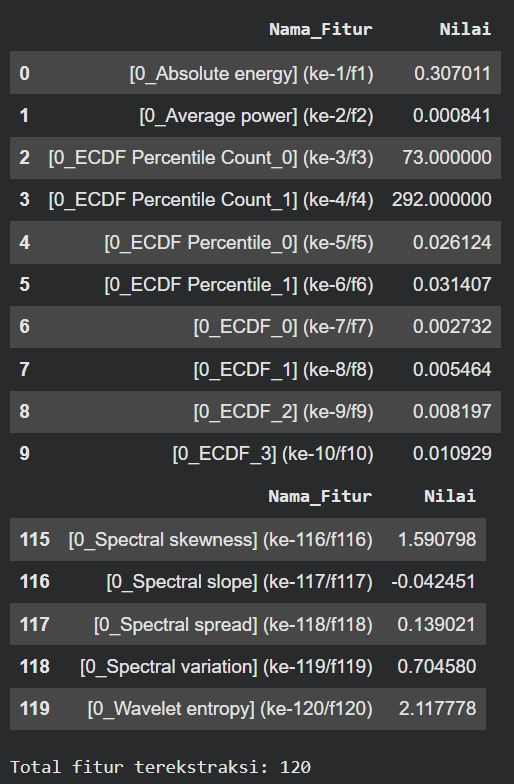

In [11]:
import numpy as np
import pandas as pd
from scipy.spatial.distance import euclidean
from scipy.stats import pearsonr
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.preprocessing import MinMaxScaler, StandardScaler

# 1. Baca data sinyal bersih dan data fitur TSFEL yang sudah dibuat sebelumnya
df_data = pd.read_csv("CO_labang_cleaned.csv")
df_fitur = pd.read_csv("Hasil_Fitur_TSFEL_CO.csv")

# 2. Otomatis Lakukan Normalisasi Fitur
scaler_minmax = MinMaxScaler()
scaler_std = StandardScaler()

nilai_array = df_fitur["Nilai"].values.reshape(-1, 1)
df_fitur["Nilai_MinMax"] = scaler_minmax.fit_transform(nilai_array)
df_fitur["Nilai_ZScore"] = scaler_std.fit_transform(nilai_array)

# Simpan hasil normalisasi fitur
df_fitur.to_csv("Hasil_Fitur_Normalized.csv", index=False)
print("File 'Hasil_Fitur_Normalized.csv' berhasil dibuat & disimpan.")

# 3. Hitung Kemiripan Sinyal Deret Waktu (Semester 1 vs Semester 2)
sinyal = df_data["CO_cleaned"].values
separuh = len(sinyal) // 2

s1 = sinyal[:separuh]
s2 = sinyal[separuh : separuh * 2]

cos_sim = cosine_similarity(s1.reshape(1, -1), s2.reshape(1, -1))[0][0]
euc_dist = euclidean(s1, s2)
corr, _ = pearsonr(s1, s2)

# 4. Rangkum Hasil Kemiripan ke dalam DataFrame
df_hasil = pd.DataFrame(
    [
        {
            "Metrik": "Cosine Similarity",
            "Nilai": cos_sim,
            "Interpretasi": "Mendekati 1 menunjukkan bentuk fluktuasi sinyal sangat mirip.",
        },
        {
            "Metrik": "Pearson Correlation",
            "Nilai": corr,
            "Interpretasi": "Mengukur korelasi linier tren harian antar periode.",
        },
        {
            "Metrik": "Euclidean Distance",
            "Nilai": euc_dist,
            "Interpretasi": "Mendekati 0 menunjukkan selisih konsentrasi harian sangat kecil.",
        },
    ]
)

print("\n=== HASIL PERHITUNGAN METRIK KEMIRIPAN CO LABANG ===")
print(df_hasil.to_string(index=False))

# 5. Simpan Ringkasan Hasil Kemiripan ke CSV
df_hasil.to_csv("Hasil_Analisis_Kemiripan_CO.csv", index=False)
print(
    "\nHasil kemiripan berhasil disimpan ke file 'Hasil_Analisis_Kemiripan_CO.csv'!"
)

File 'Hasil_Fitur_Normalized.csv' berhasil dibuat & disimpan.

=== HASIL PERHITUNGAN METRIK KEMIRIPAN CO LABANG ===
             Metrik     Nilai                                                     Interpretasi
  Cosine Similarity  0.987896    Mendekati 1 menunjukkan bentuk fluktuasi sinyal sangat mirip.
Pearson Correlation -0.042180              Mengukur korelasi linier tren harian antar periode.
 Euclidean Distance  0.062153 Mendekati 0 menunjukkan selisih konsentrasi harian sangat kecil.

Hasil kemiripan berhasil disimpan ke file 'Hasil_Analisis_Kemiripan_CO.csv'!


# Analisis Kemiripan
Analisis ini dilakukan untuk membandingkan karakteristik dan pola konsentrasi polutan CO antar rentang waktu berbeda

### Metrik Evaluasi Utama
* Cosine Similarity: Mengukur kesamaan bentuk fluktuasi sinyal tanpa terpengaruh skala absolut.

* Pearson Correlation: Mengukur tingkat kekuatan korelasi linier tren harian antar periode.

* Euclidean Distance: Menghitung jarak geometris absolut selisih konsentrasi harian.